In [1]:
import itertools
import textwrap

import cartopy.crs as ccrs
import dask.diagnostics
import faceted
import fsspec
import io
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
import virtualizarr

from obstore.store import GCSStore
from obspec_utils.registry import ObjectStoreRegistry
from upath import UPath

import plotting
from labels import UNICODE_NAMES, UNITS_UNICODE, UNITS

In [2]:
ROOT = UPath("gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference")
TIME_MEAN_DIAGNOSTICS_PATH = "time_mean_diagnostics.nc"
MODELS = {
    "SHiELD-SOM": "data-only-evaluator",
    "ACE2-SOM": "published-baseline-rs3",
    # "no-random-co2-rs0": "no-random-co2-rs0",
    # "no-random-co2-rs1": "no-random-co2-rs1",
    # "no-random-co2-energy-conserving-rs0": "no-random-co2-energy-conserving-rs0",
    # "no-random-co2-energy-conserving-rs1": "no-random-co2-energy-conserving-rs1",
    # "full-rs0": "full-rs0",
    # "full-rs1": "full-rs1",
    "full-energy-conserving-rs0": "full-energy-conserving-rs0",
    # "full-energy-conserving-rs1": "full-energy-conserving-rs1",
}
CLIMATES = ["1xCO2", "2xCO2", "3xCO2", "4xCO2"]
INITIAL_CONDITIONS = [f"ic{i}" for i in range(1, 6)]

PRECIPITATION = "PRATEsfc"
FROZEN_PRECIPITATION = "total_frozen_precipitation_rate"
SECONDS_PER_DAY = 86400

In [3]:
def safe_concat(datasets, dim, **kwargs):
    variables = set.intersection(*[set(ds.data_vars) for ds in datasets])
    return xr.concat([ds[variables] for ds in datasets], dim=dim, **kwargs)


def rename_dataset(ds):
    generated_variables = [v for v in ds.data_vars if "gen_map-" in v]
    generated = ds[generated_variables]
    rename_generated = {v: v.replace("gen_map-", "") for v in generated_variables}
    generated = generated.rename(rename_generated)
    return generated


def scale_precipitation(ds):
    if PRECIPITATION in ds:
        ds[PRECIPITATION] = SECONDS_PER_DAY * ds[PRECIPITATION]
        if FROZEN_PRECIPITATION in ds:
            ds[FROZEN_PRECIPITATION] = SECONDS_PER_DAY * ds[FROZEN_PRECIPITATION]
    return ds


def construct_path(model, climate, initial_condition):
    return str(ROOT / f"{MODELS[model]}-{climate}-{initial_condition}" / "main" / TIME_MEAN_DIAGNOSTICS_PATH)

In [4]:
registry = ObjectStoreRegistry({"gs://vcm-ml-experiments": GCSStore(bucket="vcm-ml-experiments")})
parser = virtualizarr.parsers.HDFParser()

virtual_datasets = []
for model in MODELS:
    climate_virtual_datasets = []
    for climate in CLIMATES:
        initial_condition_virtual_datasets = []
        for initial_condition in INITIAL_CONDITIONS:
            path = construct_path(model, climate, initial_condition)
            print(path)
            vds = virtualizarr.open_virtual_dataset(path, registry=registry, parser=parser)
            initial_condition_virtual_datasets.append(vds)
        combined = xr.concat(initial_condition_virtual_datasets, dim="initial_condition")
        combined = combined.assign_coords(initial_condition=INITIAL_CONDITIONS)
        climate_virtual_datasets.append(combined)
    combined = xr.concat(climate_virtual_datasets, dim="climate")
    combined = combined.assign_coords(climate=CLIMATES)
    combined.vz.to_kerchunk(f"equilibrium-climate-{model}.json", format="json")

gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference/data-only-evaluator-1xCO2-ic1/main/time_mean_diagnostics.nc
gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference/data-only-evaluator-1xCO2-ic2/main/time_mean_diagnostics.nc
gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference/data-only-evaluator-1xCO2-ic3/main/time_mean_diagnostics.nc
gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference/data-only-evaluator-1xCO2-ic4/main/time_mean_diagnostics.nc
gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference/data-only-evaluator-1xCO2-ic5/main/time_mean_diagnostics.nc
gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference/data-only-evaluator-2xCO2-ic1/main/time_mean_diagnostics.nc
gs://vcm-ml-experiments/spencerc/2026-02-20-ace-equilibrium-climate-inference/data-only-evaluator-2xCO2-ic2/main/time_mean_diagnostics.nc
gs://vcm-ml-experiments/spencerc/2

In [4]:
datasets = []
for model in MODELS:
    print(model)
    ds = xr.open_dataset(f"equilibrium-climate-{model}.json", engine="kerchunk", chunks="auto")
    ds = rename_dataset(ds)
    ds = scale_precipitation(ds)
    datasets.append(ds)
ds = xr.concat(datasets, dim=pd.Index(MODELS, name="model"))

time_mean = ds.mean("initial_condition")
time_mean_bias = time_mean.drop_sel(model="SHiELD-SOM") - time_mean.sel(model="SHiELD-SOM")

time_mean_climate_change = time_mean.drop_sel(climate="1xCO2") - time_mean.sel(climate="1xCO2")
time_mean_climate_change_bias = time_mean_climate_change.drop_sel(model="SHiELD-SOM") - time_mean_climate_change.sel(model="SHiELD-SOM")


SHiELD-SOM
ACE2-SOM
full-energy-conserving-rs0


In [5]:
land_fraction = ds.land_fraction.sel(model="SHiELD-SOM", climate="1xCO2", initial_condition="ic1").drop_vars(["model", "climate", "initial_condition"])
weights = np.cos(np.deg2rad(time_mean.lat)) * xr.concat(
    [
        xr.DataArray(1.0), 
        land_fraction, 
        1.0 - land_fraction
    ], 
    dim=pd.Index(["global", "land", "ocean-and-sea-ice"], name="region")
)

In [6]:
with dask.diagnostics.ProgressBar():
    rmse = np.sqrt((time_mean_bias ** 2).weighted(weights).mean(dim=["lat", "lon"])).compute()

[########################################] | 100% Completed | 23.14 s


In [7]:
NOISE_FLOOR_DATA_TEMPLATE = "gs://vcm-ml-intermediate/2026-04-23-vertically-resolved-1deg-c96-shield-som-{climate}-dataset-noise-floor"


def load_annual_means(climate):
    path = UPath(NOISE_FLOOR_DATA_TEMPLATE.format(climate=climate)) / "annual_means.nc"
    with fsspec.open(str(path), mode="rb") as f:
        return xr.open_dataset(f).load()


def get_stats(
    annual: xr.Dataset,
    years_per_ensemble: int,
    ensemble_members: int,
    window_size: int,
    area: xr.DataArray,
    amip: bool,
):
    """
    Gets the mean and standard deviation of the pattern bias implied by windows
    of a given number of years, from a dataset of annual means.
    """
    n_windows_per_sample = years_per_ensemble // window_size
    rmses = []
    if not amip:
        mean = annual.mean(["sample", "year"])
        annual_bias = annual - mean
    else:
        annual_bias = annual  # bias calculated on each window separately
    for i_w in range(n_windows_per_sample):
        window = annual_bias.isel(
            year=range(i_w * window_size, (i_w + 1) * window_size)
        )
        if amip:
            window = window - window.mean(["sample", "year"])
        bias_maps = window.mean("year")
        rmse = (bias_maps**2).weighted(area).mean(dim=["lat", "lon"]) ** 0.5
        if amip:
            rmse *= (ensemble_members / (ensemble_members - 1.0)) ** 0.5
        else:
            n_windows = n_windows_per_sample * ensemble_members
            rmse *= (n_windows / (n_windows - 1)) ** 0.5
        rmses.append(rmse)
    rmses_da = xr.concat(rmses, "window")
    return rmses_da


def combine_climate_stats(
    window_size: int,
    years_per_ensemble: int,
    ensemble_members: int,
    climates,
    amip: bool = False,
):
    rmses = []
    for climate in climates:
        annual = load_annual_means(climate)
        annual = annual.rename({"grid_xt": "lon", "grid_yt": "lat"})
        area = np.cos(np.deg2rad(annual.lat)).broadcast_like(annual.lon)
        rmse = get_stats(
            annual, years_per_ensemble, ensemble_members, window_size, area, amip
        )
        rmses.append(rmse)
        del annual
    rmses = xr.concat(rmses, dim="window")
    stddevs = rmses.std(["window", "sample"])
    return rmses.mean(["window", "sample"]), stddevs


def compute_noise_floor(climates):
    rmses = {}
    stddevs = {}
    for window_size in [5, 10]:
        rmses[window_size], stddevs[window_size] = combine_climate_stats(
            window_size, 10, 5, climates
        )
    rmses = xr.concat(rmses.values(), dim=pd.Index(rmses.keys(), name="window_size"))
    stddevs = xr.concat(
        stddevs.values(), dim=pd.Index(stddevs.keys(), name="window_size")
    )
    return rmses, stddevs


def apply_curvefit_result(fit, x, function):
    result = xr.Dataset()
    for variable in fit.data_vars:
        if variable.endswith("_curvefit_coefficients"):
            c = fit[variable].sel(param="c")
            result[variable.replace("_curvefit_coefficients", "")] = function(x, c)
    return result


def extrapolate(ds, window_size=50):
    def function(x, c):
        return c / np.sqrt(x)

    fit = ds.curvefit("window_size", function)
    return apply_curvefit_result(fit, window_size, function)

rmses, stddevs = compute_noise_floor(CLIMATES)
noise_floors = extrapolate(rmses, 50)
noise_floors = scale_precipitation(noise_floors)

noise_floor_stddevs = extrapolate(stddevs, 50)
noise_floor_stddevs = scale_precipitation(noise_floor_stddevs)

Exception in callback PollerCompletionQueue._handle_events()()
handle: <Handle PollerCompletionQueue._handle_events()()>
Traceback (most recent call last):
  File "/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/asyncio/events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "src/python/grpcio/grpc/_cython/_cygrpc/aio/completion_queue.pyx.pxi", line 154, in grpc._cython.cygrpc.PollerCompletionQueue._handle_events
BlockingIOError: [Errno 11] Resource temporarily unavailable


In [8]:
metrics = xr.concat(
    [
        rmse.assign_coords(model=rmse.model.to_numpy().tolist()).sel(region="global", drop=True), 
        noise_floors.assign_coords(model="noise-floor")
    ], 
    dim="model"
)
metrics = metrics[list(UNITS.keys())].drop_vars(["DSWRFtoa", "HGTsfc"])

/tmp/ipykernel_18042/2647844144.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  metrics = xr.concat(


In [9]:
# This shows that when normalized by the noise floor and then averaged over all
# variables in each climate, the full-energy-conserving-rs0 model has lower
# error than the ACE2-SOM baseline.
normalized_error = metrics.drop_sel(model="noise-floor") / metrics.sel(model="noise-floor")
normalized_error.to_array("variable").mean(["variable", "climate"])

<xarray.DataArray (model: 2)> Size: 16B
array([4.25377507, 4.0698818 ])
Coordinates:
  * model    (model) <U26 208B 'ACE2-SOM' 'full-energy-conserving-rs0'
    param    <U1 4B 'c'

In [10]:
error_bars = 2 * noise_floor_stddevs  # 95% confidence interval
error_bars = error_bars[list(metrics)]
error_bars = error_bars.to_array().sortby("variable").to_dataframe(name="error")

In [17]:
error_bars_ds = (2 * noise_floor_stddevs[list(rmses.data_vars)])
unambiguously_worse = (metrics.sel(model="ACE2-SOM", climate="3xCO2") + error_bars_ds) < (metrics.sel(model="full-energy-conserving-rs0", climate="3xCO2") - error_bars_ds)
for v, da in unambiguously_worse.items():
    if da.item():
        print(v)

total_water_path
air_temperature_2
specific_total_water_7
specific_total_water_5
Q2m


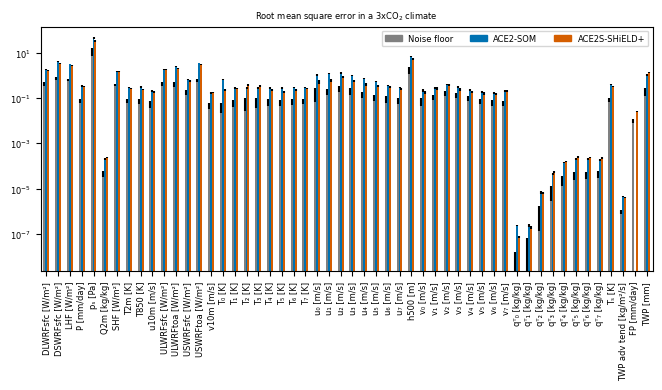

In [11]:
plotting.configure_style(fontsize=6)


BASELINE = "ACE2-SOM"
BEST_INFERENCE_MODEL = "full-energy-conserving-rs0"
COLORS = {
    "noise-floor": "gray",
    BASELINE: "C3",
    BEST_INFERENCE_MODEL: "C4",
}

UNITS_UNICODE["PRATEsfc"] = "mm/day"
UNITS_UNICODE["total_frozen_precipitation_rate"] = "mm/day"

fig, (ax,) = faceted.faceted(
    1,
    1,
    width=6.5,
    aspect=0.4,
    left_pad=0.33,
    bottom_pad=1.2,
    top_pad=0.2,
    right_pad=0.05,
)

da = metrics.sel(
    climate="3xCO2", 
    model=["noise-floor", BASELINE, BEST_INFERENCE_MODEL]
).to_array().sortby("variable")
index = pd.Index(
    [f"{UNICODE_NAMES[name]} [{UNITS_UNICODE[name]}]" for name in da["variable"].to_numpy().tolist()],
)
da = da.assign_coords(variable=index)
df = da.to_dataframe(name="RMSE").unstack(level=1)["RMSE"]

err_df = pd.DataFrame(
    np.repeat(error_bars["error"].values[:, None], len(df.columns), axis=1),
    index=df.index,
    columns=df.columns,
)
err_df = err_df.where(df.notna())

# Map the bar colors to the models using the COLORS dict, in model order
model_order = ["noise-floor", BASELINE, BEST_INFERENCE_MODEL]
bar_colors = [COLORS[mod] for mod in model_order]

# When using df.plot.bar, 'color' expects either a single color or a list of colors
# corresponding to the series (order matches the column order in df)
df.plot.bar(
    ax=ax,
    logy=True,
    yerr=err_df,
    legend=False,
    color=bar_colors
)
ax.set_xlabel("")

LEGEND_LABELS = {
    "noise-floor": "Noise floor",
    BASELINE: "ACE2-SOM",
    BEST_INFERENCE_MODEL: "ACE2S-SHiELD+",
}

# Add a legend with a patch for each color
legend_handles = [
    mpatches.Patch(color=COLORS[model], label=LEGEND_LABELS[model])
    for model in model_order
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=6, ncol=3)
ax.set_title(textwrap.fill(f"Root mean square error in a 3xCO$_2$ climate", width=70))
ax.set_ylabel("")
fig.patch.set_alpha(0.0)
fig.savefig("figure-S03.png", dpi=300)
fig.savefig("figure-S03.pdf")
